# PUDO Complaint Risk — Waymo CPUC Deployment Data (2024 Q3 – 2026 Q2)

Answers **Step 3** of the risk assessment: is the frequency of PUDO complaints rising or falling, controlling for exposure (miles driven)?

Run `pudo-build` first (or `pudo-build --no-download` if data is already extracted).

In [7]:
from pathlib import Path
import os
import polars as pl
import matplotlib.pyplot as plt

DATA = Path(os.environ.get("PUDO_DATA_DIR", "../data")) / "parquet"
summary = pl.read_parquet(DATA / "pudo_summary.parquet")
monthly = pl.read_parquet(DATA / "monthly_activity.parquet")
complaints = pl.read_parquet(DATA / "complaints.parquet")
# summary
monthly

TCPID,TotalTrips,TotalVMTPeriod1,TotalVMTPeriod2,TotalVMTPeriod3,TotalVMTZEV,TotalPassengersCarried,TotalPMT,period_id,company,year,month,quarter,vmt_total
str,f64,f64,f64,f64,f64,f64,f64,str,str,i32,i8,i8,f64
"""PSG0038152""",188847.0,424530.89,169059.05,523809.59,1.1174e6,291644.0,799159.95,"""2024P3_JunAug""","""Waymo""",2024,6,2,1.1174e6
"""PSG0038152""",250752.0,546915.07,206038.6,686511.35,1.4395e6,406590.0,1.0949e6,"""2024P3_JunAug""","""Waymo""",2024,7,3,1.4395e6
"""PSG0038152""",312245.0,658598.23,272304.22,897938.83,1.8288e6,499170.0,1.3978e6,"""2024P3_JunAug""","""Waymo""",2024,8,3,1.8288e6
"""PSG0038152""",null,null,null,null,null,null,null,"""2024P4_SepNov""","""Waymo""",2024,9,3,0.0
"""PSG0038152""",null,null,null,null,null,null,null,"""2024P4_SepNov""","""Waymo""",2024,10,4,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PSG0038152""",null,null,null,null,null,null,null,"""2025Q3""","""Waymo""",2025,8,3,0.0
"""PSG0038152""",null,null,null,null,null,null,null,"""2025Q3""","""Waymo""",2025,9,3,0.0
"""PSG0038152""",null,null,null,null,null,null,null,"""2025Q4""","""Waymo""",2025,10,4,0.0


In [8]:
summary

period_id,year,quarter,company,pudo_complaints,pudo_travel_lane,pudo_collisions,total_incident_rows,vmt,trips,n_months,pudo_per_100k_vmt,pudo_per_100k_trips
str,i64,i64,str,u32,u32,u32,u32,f64,f64,u32,f64,f64
"""2024P3_JunAug""",2024,3,"""Waymo""",0,0,0,1,4.3857e6,751844.0,3,0.0,0.0
"""2024P4_SepNov""",2024,4,"""Waymo""",0,0,0,1,null,null,3,null,null
"""2024P5_Dec""",2024,4,"""Waymo""",0,0,0,1,null,null,1,null,null
"""2025Q1""",2025,1,"""Waymo""",27,0,33,2631228,null,null,3,null,null
"""2025Q2""",2025,2,"""Waymo""",42,0,54,3151218,null,null,3,null,null
"""2025Q3""",2025,3,"""Waymo""",42,0,46,3747947,null,null,3,null,null
"""2025Q4""",2025,4,"""Waymo""",66,0,50,4496264,null,null,3,null,null
"""2026Q1""",2026,1,"""Waymo""",69,0,69,4922696,null,null,3,null,null
"""2026Q2""",2026,2,"""Waymo""",79,0,63,4888011,null,null,3,null,null


In [9]:
complaints

TCPID,period_id,year,quarter,month,company,source_file,CollisionPUDOPassenger,CollisionPUDOPedestrian,CollisionPUDOBicycleScooter,CollisionPUDOMotorcycles,CollisionPUDOOtherVehicle,CollisionPUDORail,CollisionPUDOProperty,PUDOTravelLane,ComplaintSafety,ComplaintPUDO,ComplaintAccessibility,ComplaintWAV,ComplaintCustomerService,ComplaintOther,CollisionPUDOAny
str,str,i32,i8,i8,str,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""PSG0039080""","""2024P3_JunAug""",2024,3,null,"""Waymo""","""PSG0039080_202410_AV_Incidents…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PSG0038152""","""2024P4_SepNov""",2024,4,null,"""Waymo""","""PSG0038152_2025_02_(Sep_1-Nov_…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PSG0038152""","""2024P5_Dec""",2024,4,null,"""Waymo""","""PSG0038152_2025_02_(Dec_1-Dec_…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PSG0038152""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
"""PSG0038152""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PSG0038152""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
"""PSG0038152""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
"""PSG0038152""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false,false,false,false,false,false,false,false,false,false,false,false,false,false,false


## 1. Raw counts vs. exposure

Raw complaint counts are expected to rise simply because Waymo's service grew enormously over this window — VMT is the control.

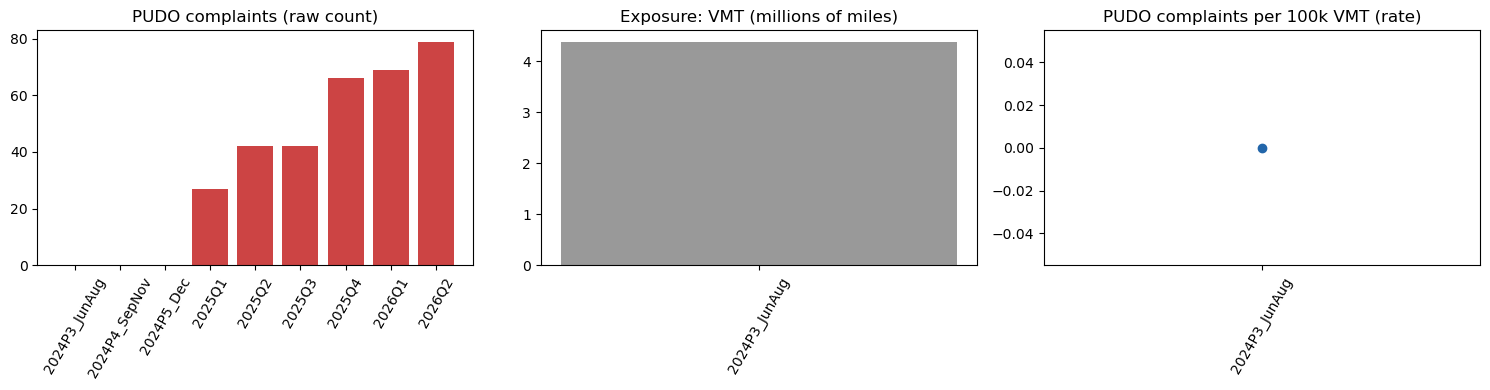

In [2]:
s = summary.to_pandas()
labels = s["period_id"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(labels, s["pudo_complaints"], color="#c44")
axes[0].set_title("PUDO complaints (raw count)")
axes[1].bar(labels, s["vmt"] / 1e6, color="#999")
axes[1].set_title("Exposure: VMT (millions of miles)")
axes[2].plot(labels, s["pudo_per_100k_vmt"], marker="o", color="#26a")
axes[2].set_title("PUDO complaints per 100k VMT (rate)")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## 2. Trend test — Poisson regression with exposure offset

Model: `pudo_complaints ~ time_index`, `offset = log(VMT)`.
The exponentiated time coefficient is the multiplicative change in the complaint *rate* per reporting period. The Dec-2024 one-month stub period is handled naturally by the offset (smaller exposure, smaller expected count).

In [3]:
import numpy as np
import statsmodels.api as sm

d = s.dropna(subset=["pudo_complaints", "vmt"]).reset_index(drop=True)
d["t"] = range(len(d))
X = sm.add_constant(d["t"])
model = sm.GLM(
    d["pudo_complaints"], X,
    family=sm.families.Poisson(),
    offset=np.log(d["vmt"]),
).fit()
print(model.summary())

rate_change = np.exp(model.params["t"]) - 1
ci = np.exp(model.conf_int().loc["t"]) - 1
direction = "RISING" if rate_change > 0 else "FALLING"
print(f"\nPUDO complaint rate is {direction}: "
      f"{rate_change:+.1%} per period (95% CI {ci[0]:+.1%} to {ci[1]:+.1%}), "
      f"p = {model.pvalues['t']:.4f}")

/home/jon/anaconda3/envs/or568_ml_project/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:445: RuntimeWarning: invalid value encountered in divide
  endog_mu = self._clean(endog / mu)


ValueError: The first guess on the deviance function returned a nan.  This could be a boundary  problem and should be reported.

If the Poisson model is overdispersed (check: Pearson chi2 / df residuals >> 1 in the summary above), rerun with `sm.families.NegativeBinomial()` and report that instead — same interpretation.

## 3. Supporting views: travel-lane PUDO and PUDO collisions

`PUDOTravelLane` (AV performing PUDO while stopped in a travel lane) is the safety-adjacent signal; `pudo_collisions` are actual collisions during PUDO. Keeping them separate from customer complaints strengthens the severity argument.

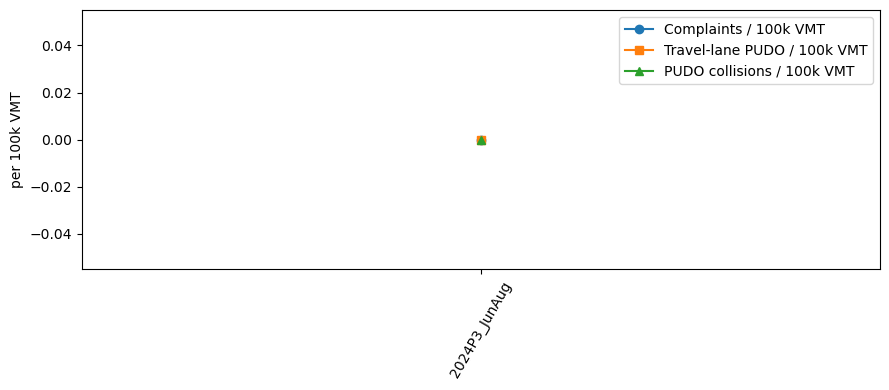

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(labels, s["pudo_per_100k_vmt"], marker="o", label="Complaints / 100k VMT")
ax.plot(labels, s["pudo_travel_lane"] / s["vmt"] * 1e5, marker="s",
        label="Travel-lane PUDO / 100k VMT")
ax.plot(labels, s["pudo_collisions"] / s["vmt"] * 1e5, marker="^",
        label="PUDO collisions / 100k VMT")
ax.tick_params(axis="x", rotation=60)
ax.set_ylabel("per 100k VMT")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Risk-chart placement

- **Likelihood**: read directly off the rate series above — PUDO complaints are the *most frequent* incident class in this dataset (high likelihood).
- **Severity**: predominantly low (customer inconvenience, curb/lane obstruction); the PUDO-collision series shows how rarely it escalates to physical harm.
- **Placement**: high-likelihood / low-consequence cell → typically the *medium / monitor-and-mitigate* band of a 5×5 matrix.
- **Direction arrow**: use the trend-test result — a rising exposure-adjusted rate argues the risk is migrating upward and merits active mitigation (designated PUDO zones, curb-space management); a falling rate supports monitor-only.

*(Fill in the final placement sentence after running the trend test on the real data — match the axes/labels of the risk chart from the class slide.)*